<a href="https://colab.research.google.com/github/Riky-18/XGBoost-Task/blob/main/RF%26NB_Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 5: Random Forest vs Naïve Bayes – Student Performance<br>
A school wants to predict if a student will pass or fail based on study habits.<br><br>
https://www.kaggle.com/datasets/prekshad2166/student-study-habits <br><br>
Features: Study_hours , Attendance_rate , Assignments_completed , Sleep_hours, parental_education<br>
<br>
Task:

 Train both a Random Forest classifier and a Naïve Bayes classifier to predict student performance. Compare their accuracy and determine which model performs better. Additionally, predict the outcome for a student with the following attributes:

*   study_hours = 15
*   attendance_rate = 90%
*   assignments_completed = 10
*   sleep_hours = 8
*   parental_education = 'Bachelor's Degree'

<hr>
<hr>







Setup & Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')

Load & Quick Check

In [ ]:
df = pd.read_csv('student_study_habits.csv')
print("Shape:", df.shape)
df.head()

Shape: (500, 13)


,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
0,0.527230,0.685236,0.993245,0.222222,71.104897,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.421400,0.881883,0.883478,0.555556,62.240021,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.552393,0.220286,0.683469,1.000000,65.268855,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.698283,0.612594,0.520094,0.222222,66.609921,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.405419,0.369871,0.831127,0.333333,58.967484,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
df.info()
print("Any nulls?:", df.isnull().any().any())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   study_hours_per_week            500 non-null    float64
 1   sleep_hours_per_day             500 non-null    float64
 2   attendance_percentage           500 non-null    float64
 3   assignments_completed           500 non-null    float64
 4   final_grade                     500 non-null    float64
 5   participation_level_Low         500 non-null    float64
 6   participation_level_Medium      500 non-null    float64
 7   internet_access_Yes             500 non-null    float64
 8   parental_education_High School  500 non-null    float64
 9   parental_education_Master's     500 non-null    float64
 10  parental_education_PhD          500 non-null    float64
 11  extracurricular_Yes             500 non-null    float64
 12  part_time_job_Yes               500 

Create Target Variable

In [ ]:
df['passed'] = (df['final_grade'] >= 60).astype(int)

print(df['passed'].value_counts())
print(f"Pass percentage: {df['passed'].mean() * 100:.1f}%")

passed
1    338
0    162
Name: count, dtype: int64
Pass percentage: 67.6%


Simple Visualizations (EDA)

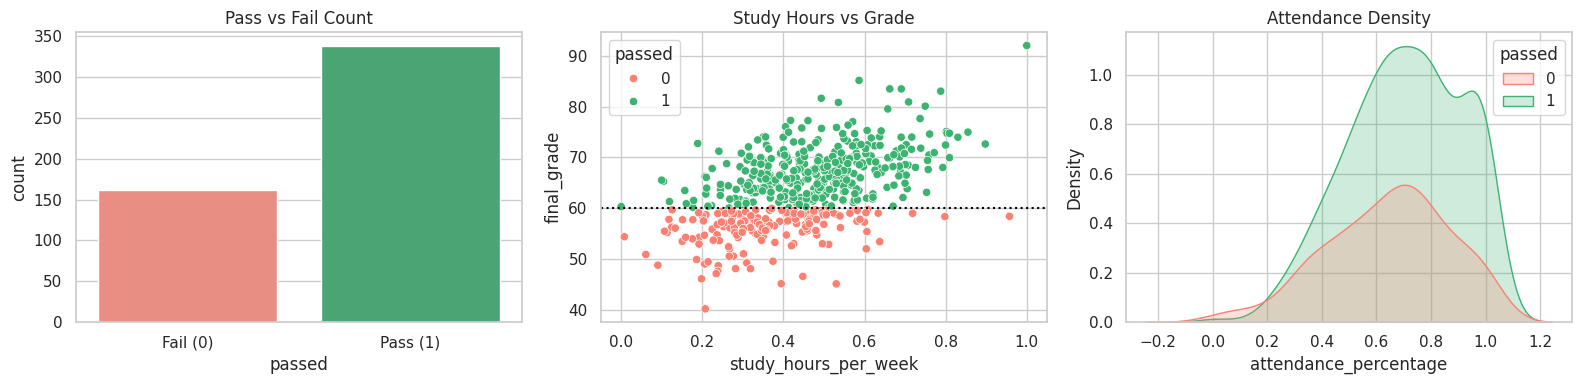

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Target count
sns.countplot(data=df, x='passed', palette=['salmon', 'mediumseagreen'], ax=axes[0])
axes[0].set_title("Pass vs Fail Count")
axes[0].set_xticklabels(['Fail (0)', 'Pass (1)'])

# 2. Study hours vs Final Grade
sns.scatterplot(data=df, x='study_hours_per_week', y='final_grade', hue='passed', palette=['salmon', 'mediumseagreen'], ax=axes[1])
axes[1].axhline(60, color='black', linestyle=':')
axes[1].set_title("Study Hours vs Grade")

# 3. Attendance distribution
sns.kdeplot(data=df, x='attendance_percentage', hue='passed', fill=True, palette=['salmon', 'mediumseagreen'], ax=axes[2])
axes[2].set_title("Attendance Density")

plt.tight_layout()
plt.show()

Select Features & Train-Test Split

In [ ]:
feature_cols = [
    'study_hours_per_week',
    'attendance_percentage',
    'assignments_completed',
    'sleep_hours_per_day',
    'parental_education_High School',
    'parental_education_Master\'s',
    'parental_education_PhD'
]

X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train samples: 400 | Test samples: 100


 Train Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=4,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")

Random Forest Accuracy: 77.00%


Train Naïve Bayes

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
print(f"Naïve Bayes Accuracy: {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")

Naïve Bayes Accuracy: 75.00%


Direct Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gaussian Naïve Bayes'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_nb)]
})

results['Accuracy'] = results['Accuracy'].apply(lambda x: f"{x * 100:.2f}%")
display(results)

print("\n--- Detailed Classification Reports ---")
print("RF:\n", classification_report(y_test, y_pred_rf))
print("NB:\n", classification_report(y_test, y_pred_nb))

,Model,Accuracy
0,Random Forest,77.00%
1,Gaussian Naïve Bayes,75.00%



--- Detailed Classification Reports ---
RF:
               precision    recall  f1-score   support

           0       0.67      0.56      0.61        32
           1       0.81      0.87      0.84        68

    accuracy                           0.77       100
   macro avg       0.74      0.72      0.72       100
weighted avg       0.76      0.77      0.76       100

NB:
               precision    recall  f1-score   support

           0       0.61      0.62      0.62        32
           1       0.82      0.81      0.81        68

    accuracy                           0.75       100
   macro avg       0.71      0.72      0.72       100
weighted avg       0.75      0.75      0.75       100



Confusion Matrices

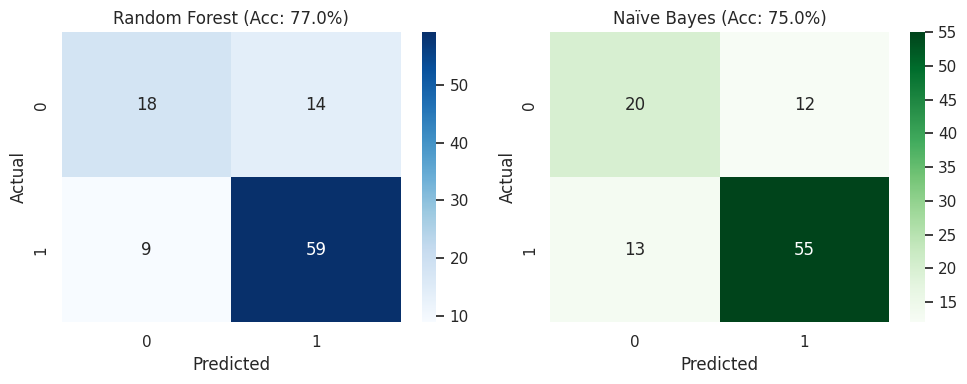

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f"Random Forest (Acc: {accuracy_score(y_test, y_pred_rf)*100:.1f}%)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f"Naïve Bayes (Acc: {accuracy_score(y_test, y_pred_nb)*100:.1f}%)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Predict for the New Student

In [ ]:
# Real-world student input
raw_study_hours = 15          # hrs/week (Assuming max 27 hrs)
raw_attendance = 90           # 90%
raw_assignments = 10          # 10 out of 10
raw_sleep_hours = 8           # hrs/day (Assuming max 12 hrs)

# Convert to dataset scale (0 to 1)
test_student = pd.DataFrame([{
    'study_hours_per_week'          : raw_study_hours / 27.0,     # -> 0.55
    'attendance_percentage'         : raw_attendance / 100.0,     # -> 0.90
    'assignments_completed'         : raw_assignments / 10.0,     # -> 1.00
    'sleep_hours_per_day'           : raw_sleep_hours / 12.0,     # -> 0.67
    'parental_education_High School': 0.0,
    'parental_education_Master\'s'  : 0.0,
    'parental_education_PhD'        : 0.0
}])

# Predictions
rf_res = rf.predict(test_student)[0]
rf_prob = rf.predict_proba(test_student)[0]

nb_res = nb.predict(test_student)[0]
nb_prob = nb.predict_proba(test_student)[0]

print(f"Random Forest  : {'PASS' if rf_res == 1 else 'FAIL'} (Confidence: {rf_prob[1]*100:.1f}%)")
print(f"Naïve Bayes    : {'PASS' if nb_res == 1 else 'FAIL'} (Confidence: {nb_prob[1]*100:.1f}%)")

Random Forest  : PASS (Confidence: 90.3%)
Naïve Bayes    : PASS (Confidence: 95.0%)
